# Canny Edge Detection: Essential Validation & Enhancement Study

This notebook evaluates four algorithm-specific Canny configurations on the 139-image validation split. Every configuration uses the predetermined shared preprocessing pipeline: 3×3 Gaussian denoising followed by CLAHE (clip limit 2.0, tile grid 8×8). Only Canny-specific thresholds and post-processing settings differ. The highest aggregate F1-score at IoU 0.50 determines the frozen configuration.

### Enhancement Strategy:
1. **Validation reference configuration**: Canny edge differencing without Canny-specific morphology or area filtering; shared Gaussian+CLAHE preprocessing remains enabled.
2. **Morphological Closing (`cv2.MORPH_CLOSE`)**: Bridges fragmented edge contours into solid polygon regions.
3. **Minimum Area Filtering (`min_area`)**: Eliminates high-frequency trace edge noise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'validation' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from algorithms.common import load_image, preprocess_pair
from algorithms.evaluation import evaluate_boxes, parse_voc_boxes
from algorithms.canny import detect_canny
from algorithms.preprocessing import build_preprocessing_config

plt.rcParams['figure.dpi'] = 110
print(f'Project Root: {PROJECT_ROOT}')

# Smart auto-run fallback: auto-compute benchmark if outputs/metrics CSV is missing
res_csv = PROJECT_ROOT / 'outputs' / 'metrics' / 'essential_validation_comparison.csv'
if not res_csv.exists():
    print('⚠️ Validation metrics CSV not found. Auto-running validation benchmark on 139 validation images...')
    from scripts.evaluation.run_essential_validation import main as run_benchmark
    run_benchmark()
    print('✅ Benchmark successfully generated!')


Project Root: C:\Users\jieer\Documents\GitHub\pcb-defects-inspection


## 1. Essential Validation Results (4 Core Configurations)

In [2]:
df = pd.read_csv(res_csv)
df['description'] = df['description'].replace({'Raw edge difference (low=50, high=150, no morph)': 'Validation reference: shared preprocessing + low=50, high=150; no Canny-specific morphology'})
canny_df = df[df['algorithm'] == 'Canny'][['combination_id', 'description', 'precision', 'recall', 'f1_score', 'mean_runtime_ms']]
display(canny_df)


,combination_id,description,precision,recall,f1_score,mean_runtime_ms
8,Canny-Baseline,Validation reference: shared preprocessing + l...,0.000002,0.017212,0.000005,376.941131
9,Canny-Closed-Area150,Edge difference with closing 5 + min_area 150,0.009929,0.118761,0.018327,233.082398
10,Canny-LowThresh-Area300,"Sensitive low=30, high=100 with closing 5 + mi...",0.008473,0.208262,0.016283,250.486652
11,Canny-Best-Area300,"Optimal low=50, high=150 with closing 5 + min_...",0.034254,0.115318,0.052818,228.628376


## 2. Visual Comparison of Canny Configurations

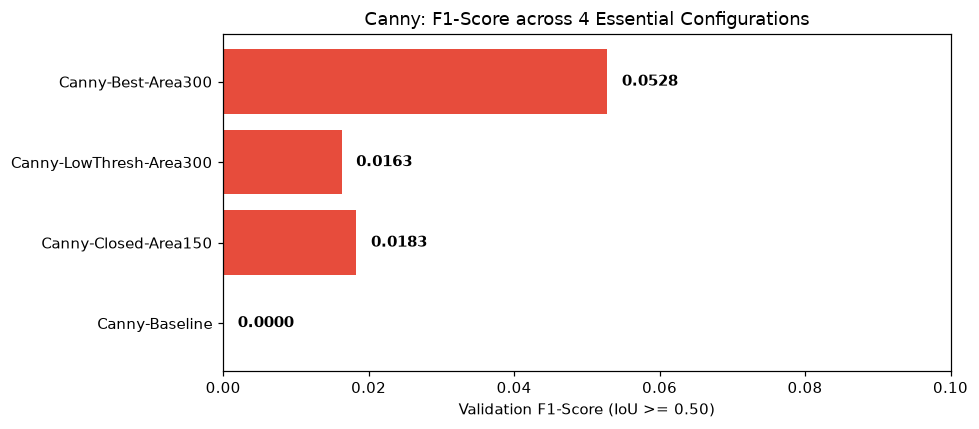

In [3]:
plt.figure(figsize=(9, 4))
plt.barh(canny_df['combination_id'], canny_df['f1_score'], color='#e74c3c')
plt.xlabel('Validation F1-Score (IoU >= 0.50)')
plt.title('Canny: F1-Score across 4 Essential Configurations')
plt.xlim(0, 0.10)
for i, v in enumerate(canny_df['f1_score']):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Visual Detection Overlay on Defect Samples

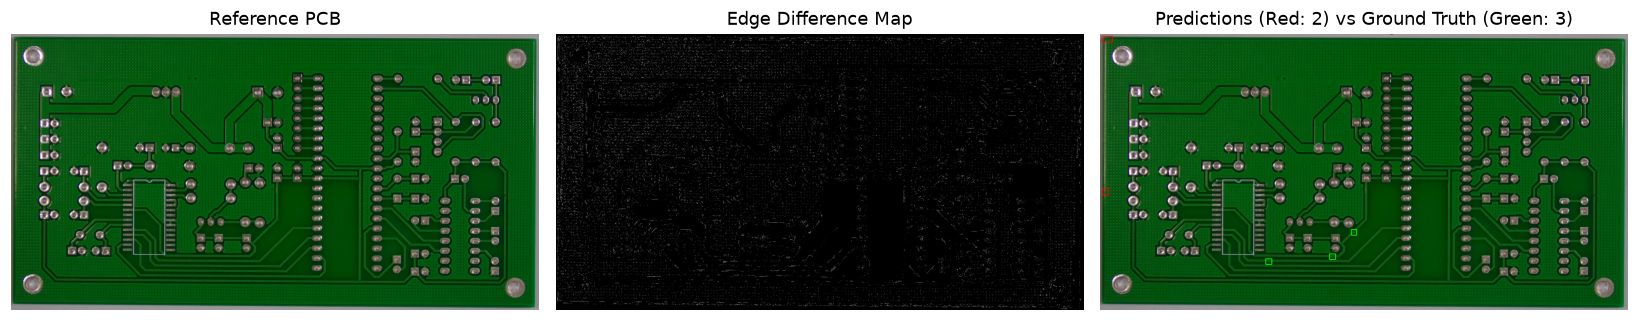

In [4]:
with open(PROJECT_ROOT / 'configs' / 'frozen_parameters.yaml') as f:
    cfg = yaml.safe_load(f)
prep_cfg = build_preprocessing_config(cfg.get('preprocessing'))
canny_cfg = cfg['canny']

manifest = pd.read_csv(PROJECT_ROOT / 'data' / 'dataset_split.csv')
val_subset = manifest[manifest['split'] == 'validation']
sample_row = val_subset[val_subset['defect_class'] == 'spur'].iloc[0]

ref = load_image(PROJECT_ROOT / sample_row['reference_path'])
def_img = load_image(PROJECT_ROOT / sample_row['image_path'])
gt_boxes = parse_voc_boxes(PROJECT_ROOT / sample_row['annotation_path'])

det = detect_canny(ref, def_img, low_threshold=canny_cfg['low_threshold'], high_threshold=canny_cfg['high_threshold'], aperture_size=canny_cfg['aperture_size'], l2_gradient=canny_cfg['l2_gradient'], morph_dilate=canny_cfg['morph_dilate'], morph_close=canny_cfg['morph_close'], min_area=canny_cfg['min_area'], preprocessing_config=prep_cfg)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB))
axes[0].set_title('Reference PCB')
axes[0].axis('off')

axes[1].imshow(det.edge_difference, cmap='gray')
axes[1].set_title('Edge Difference Map')
axes[1].axis('off')

overlay = cv2.cvtColor(def_img.copy(), cv2.COLOR_BGR2RGB)
for b in gt_boxes:
    cv2.rectangle(overlay, (int(b['xmin']), int(b['ymin'])), (int(b['xmax']), int(b['ymax'])), (0, 255, 0), 4)
for b in det.boxes:
    cv2.rectangle(overlay, (int(b['xmin']), int(b['ymin'])), (int(b['xmax']), int(b['ymax'])), (255, 0, 0), 3)
axes[2].imshow(overlay)
axes[2].set_title(f'Predictions (Red: {len(det.boxes)}) vs Ground Truth (Green: {len(gt_boxes)})')
axes[2].axis('off')
plt.tight_layout()
plt.show()
